# ARIA: Automated Regional Impact Auditor

Week 3 flood-risk assessment for shelters near rivers in Taiwan.


## Data Sources

- River polygons: `data/RIVERPOLY/riverpoly/riverpoly.shp`
- Shelter CSV: `data/避難收容處所點位檔案v9.csv`
- Township boundaries: `data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp`
- Township population workbook: `data/鄉鎮戶數及人口數-115年2月.xls`


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import IFrame, Image, display

project_root = Path.cwd().resolve()
for candidate in [project_root, *project_root.parents]:
    if (candidate / 'scripts' / 'aria_pipeline.py').exists():
        project_root = candidate
        break
    if candidate.name == 'scripts' and (candidate / 'aria_pipeline.py').exists():
        project_root = candidate.parent
        break
else:
    raise ModuleNotFoundError('scripts/aria_pipeline.py not found from the current notebook location')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.aria_pipeline import (
    build_config_from_env,
    load_population_table,
    load_shelter_table,
    load_townships,
    run_aria_pipeline,
)

config = build_config_from_env()
config


ARIAConfig(river_shp_path=WindowsPath('D:/YongZhi/2026_RS/data/RIVERPOLY/riverpoly/riverpoly.shp'), shelter_csv_path=WindowsPath('D:/YongZhi/2026_RS/data/避難收容處所點位檔案v9.csv'), township_shp_path=WindowsPath('D:/YongZhi/2026_RS/data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp'), population_xls_path=WindowsPath('D:/YongZhi/2026_RS/data/鄉鎮戶數及人口數-115年2月.xls'), buffer_high=500, buffer_med=1000, buffer_low=2000, gap_ratio=0.2, output_dir=WindowsPath('D:/YongZhi/2026_RS/outputs/aria'), submission_dir=WindowsPath('D:/YongZhi/2026_RS/submission/Homework-3'))

## Shelter Preview

Load the raw shelter table before the spatial cleaning stages.


In [2]:
raw_shelters = load_shelter_table(config.shelter_csv_path)
raw_shelters.head()


,shelter_id,name,capacity,longitude,latitude,is_indoor
0,1,五峰活動中心,110,121.073000,24.386000,True
1,2,金門縣烈嶼鄉林湖村辦公處,30,118.248571,24.428328,True
2,3,南坑村集會所暨南外社區活動中心,20,121.056100,24.672500,False
3,4,烏坵鄉小坵村活動中心,20,119.470000,24.980000,False
4,5,金門縣烏坵鄉公所大廳,30,119.453178,24.988739,False


## Township And Population Preview

The township boundary shapefile is used both as the Taiwan land mask and the township aggregation base.


In [3]:
townships = load_townships(config.township_shp_path)
population = load_population_table(config.population_xls_path)
townships[['COUNTYNAME', 'TOWNNAME']].head(), population.head()


(  COUNTYNAME TOWNNAME
 0        臺東縣      成功鎮
 1        屏東縣      佳冬鄉
 2        雲林縣      麥寮鄉
 3        臺東縣      綠島鄉
 4        臺東縣      蘭嶼鄉,
   COUNTYNAME TOWNNAME  households  population    male  female
 0        新北市      板橋區      238569      549515  265180  284335
 1        新北市      三重區      172913      382749  186440  196309
 2        新北市      中和區      183037      403396  193400  209996
 3        新北市      永和區       95788      211205   99363  111842
 4        新北市      新莊區      177321      420922  203732  217190)

## Run The ARIA Pipeline

This generates the JSON audit, township summaries, interactive HTML map, static PNG chart, and the submission folder.


In [4]:
result = run_aria_pipeline(config)
result


ARIAResult(cleaning_summary_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/cleaning_summary.json'), population_summary_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/population_summary.csv'), township_summary_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/township_summary.csv'), top10_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/top10_townships.csv'), risk_json_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/shelter_risk_audit.json'), risk_html_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/risk_map.html'), risk_png_path=WindowsPath('D:/YongZhi/2026_RS/outputs/aria/risk_map.png'), submission_dir=WindowsPath('D:/YongZhi/2026_RS/submission/Homework-3'))

## Display Outputs Inline

Show the generated summaries and visual outputs directly inside the notebook instead of only printing file paths.


,value
raw_shelter_rows,5973
removed_null_or_zero_coordinate_rows,3
removed_outside_taiwan_land_mask_rows,63
valid_shelter_rows,5907


,TOWNCODE,COUNTYNAME,TOWNNAME,households,population,male,female,high_count,medium_count,low_count,safe_count,high_capacity,medium_capacity,low_capacity,safe_capacity,risk_capacity,required_safe_capacity,capacity_gap,gap_flag
0,65000010,新北市,板橋區,238569,549515,265180,284335,10,12,9,0,11129,13982,12498,0,37609,109903.0,109903.0,True
1,68000010,桃園市,桃園區,209386,478629,229534,249095,25,19,10,2,13049,4165,8400,154,25614,95725.8,95571.8,True
2,68000020,桃園市,中壢區,190770,439290,213576,225714,52,20,22,0,35254,9190,14528,0,58972,87858.0,87858.0,True
3,65000050,新北市,新莊區,177321,420922,203732,217190,17,10,9,0,12743,6443,6862,0,26048,84184.4,84184.4,True
4,65000030,新北市,中和區,183037,403396,193400,209996,1,9,12,0,92,11211,16182,0,27485,80679.2,80679.2,True
5,65000020,新北市,三重區,172913,382749,186440,196309,8,14,14,0,8821,6112,15085,0,30018,76549.8,76549.8,True
6,64000120,高雄市,鳳山區,154865,352745,170690,182055,13,12,11,0,11856,12416,14274,0,38546,70549.0,70549.0,True
7,64000050,高雄市,三民區,149899,328532,156619,171913,24,7,7,0,20328,4909,9480,0,34717,65706.4,65706.4,True
8,66000080,臺中市,北屯區,137901,317532,150057,167475,17,12,3,0,16026,12244,1433,0,29703,63506.4,63506.4,True
9,65000060,新北市,新店區,143782,306636,146119,160517,26,7,1,0,26112,13423,250,0,39785,61327.2,61327.2,True


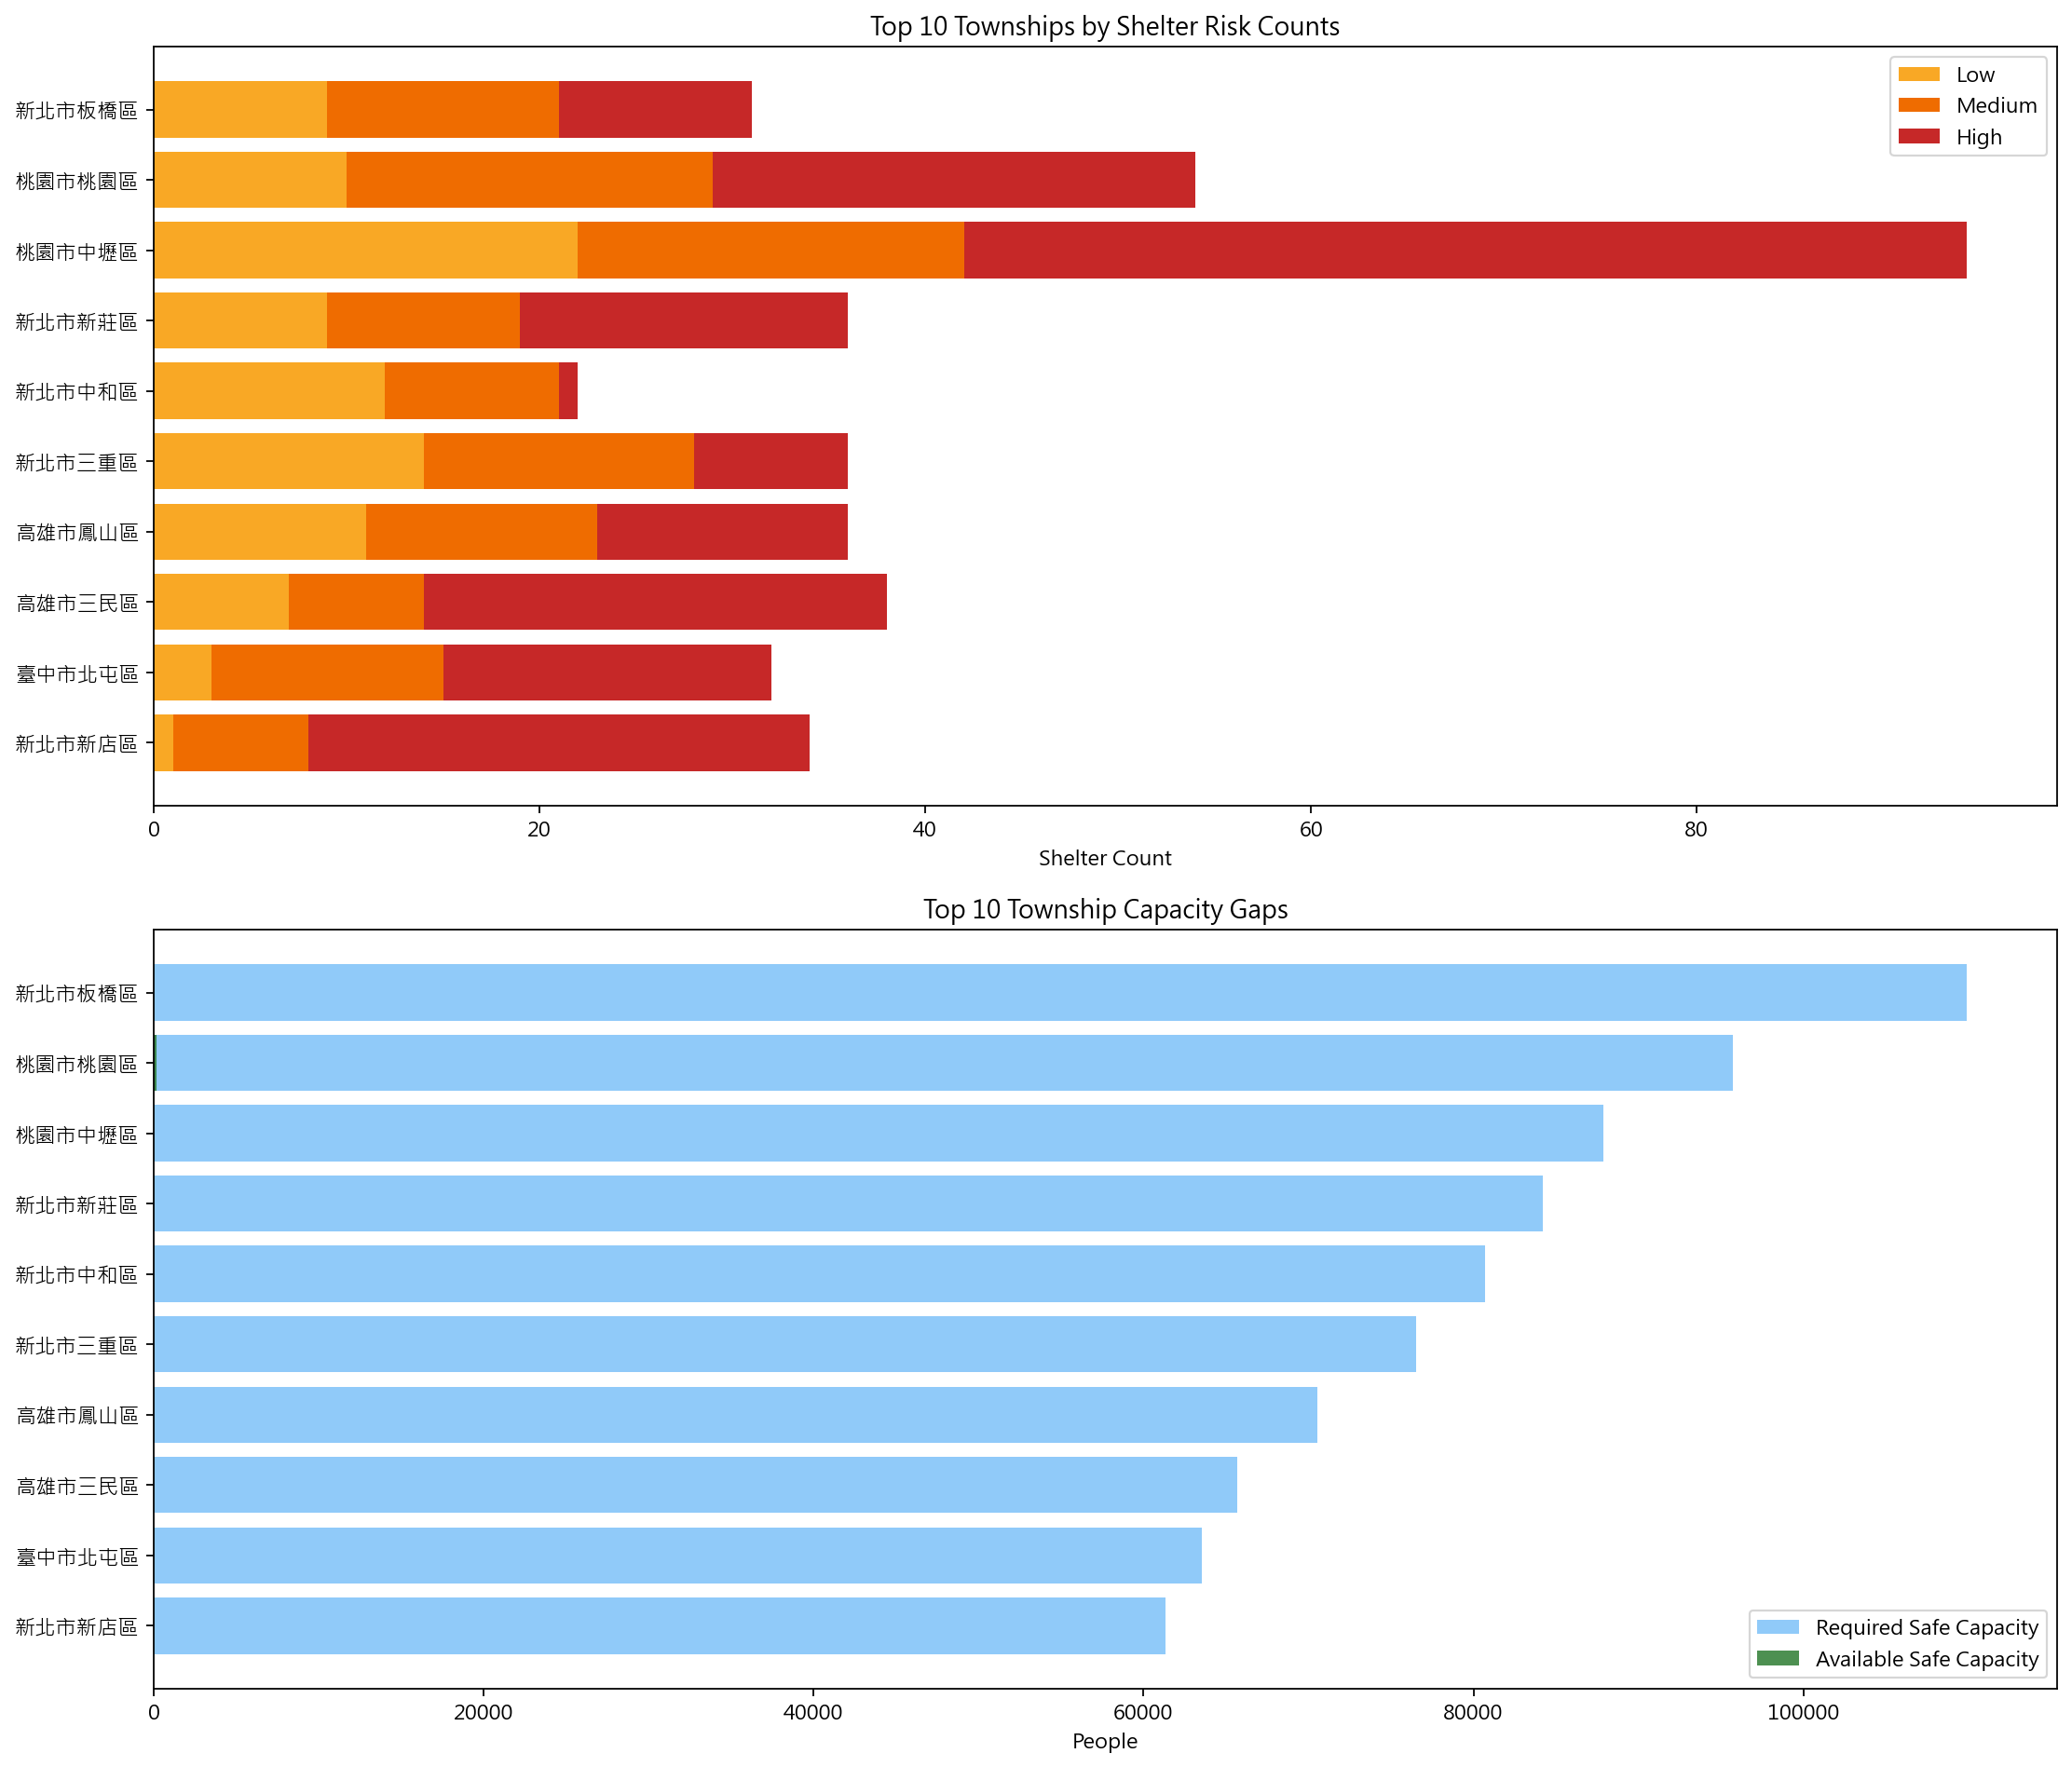

In [5]:
cleaning_summary = pd.read_json(result.cleaning_summary_path, typ='series')
top10 = pd.read_csv(result.top10_path, encoding='utf-8-sig')

display(cleaning_summary.to_frame('value'))
display(top10.head(10))
display(Image(filename=str(result.risk_png_path)))
IFrame(src=Path(result.risk_html_path).resolve().as_uri(), width=1000, height=720)


## AI Diagnostic Log

- The original repository was centered on AQI analysis, so Homework 3 was isolated into `scripts/aria_pipeline.py`.
- The `.xls` population workbook requires `xlrd==2.0.1` in the `geopandas` environment.
- Taiwan extent validation uses the township boundary shapefile instead of a hard-coded lon/lat box.
- The notebook now renders the generated HTML map and PNG chart inline, so the outputs are visible immediately after execution.
